In [6]:
# Common imports for Section B (run once)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True



Missing Value Summary:
age             2
region          0
purchases       1
premium_user    0
dtype: int64
Unique Values Per Column:
age             5
region          4
purchases       6
premium_user    2
dtype: int64
Correlation Among Numeric Columns:
                   age  purchases  premium_user
age           1.000000   0.923677      0.789534
purchases     0.923677   1.000000      0.825860
premium_user  0.789534   0.825860      1.000000


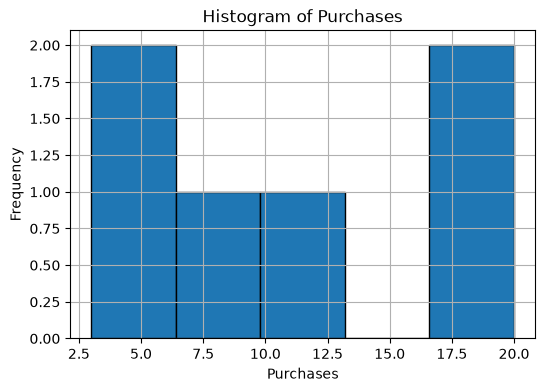

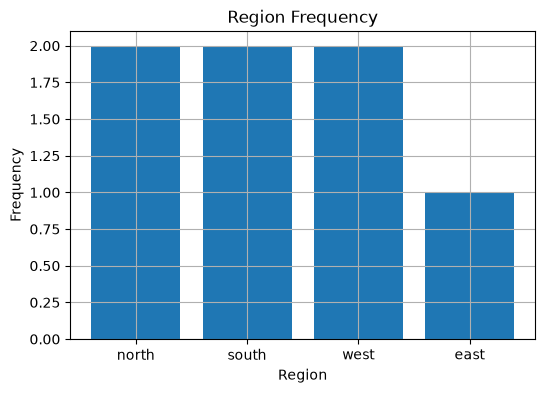

In [7]:
# Q4 – Student Answer

# Step 1: Create the dataframe
df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})

#Compact EDA using pandas
print("Missing Value Summary:")
print(df.isnull().sum())

print("Unique Values Per Column:")
print(df.nunique())


print("Correlation Among Numeric Columns:")
print(df.corr(numeric_only=True))

plt.figure(figsize=(6, 4))
plt.hist(df["purchases"].dropna(), bins=5, edgecolor="black")
plt.xlabel("Purchases")
plt.ylabel("Frequency")
plt.title("Histogram of Purchases")
plt.show()

region_frequency = df["region"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(region_frequency.index, region_frequency.values)
plt.xlabel("Region")
plt.ylabel("Frequency")
plt.title("Region Frequency")
plt.show()

In [8]:

from sklearn.preprocessing import OneHotEncoder, RobustScaler
# Preprocess the dataset using sklearn plus pandas
# 1. Impute age with median

age_imputer = SimpleImputer(strategy="median")
df["age"] = age_imputer.fit_transform(df[["age"]]).ravel()

# 2. Impute purchases with mean
purchase_imputer = SimpleImputer(strategy="mean")
df["purchases"] = purchase_imputer.fit_transform(
    df[["purchases"]]
).ravel()

# 3. One-hot encode region

encoder = OneHotEncoder(sparse_output=False)

region_encoded = encoder.fit_transform(df[["region"]])

region_columns = encoder.get_feature_names_out(["region"])

region_df = pd.DataFrame(
    region_encoded,
    columns=region_columns,
    index=df.index
)

# Remove original region and add encoded columns
df = pd.concat(
    [df.drop("region", axis=1), region_df],
    axis=1
)

# 4. Scale numeric columns
numeric_columns = ["age", "purchases"]

scaler = RobustScaler()

df[numeric_columns] = scaler.fit_transform(
    df[numeric_columns]
)

# Display final dataset
print("Preprocessed Dataset:")
print(df)



Preprocessed Dataset:
   age  purchases  premium_user  region_east  region_north  region_south  \
0 -0.5  -0.943820             0          0.0           1.0           0.0   
1  0.0   0.000000             1          0.0           0.0           1.0   
2  0.0  -0.674157             0          0.0           1.0           0.0   
3 -0.8   0.112360             0          1.0           0.0           0.0   
4  1.5   1.348315             1          0.0           0.0           0.0   
5  2.2   1.078652             1          0.0           0.0           0.0   
6  0.0  -0.134831             0          0.0           0.0           1.0   

   region_west  
0          0.0  
1          0.0  
2          0.0  
3          0.0  
4          1.0  
5          1.0  
6          0.0  


In [9]:
df["high_spender"] = (df["purchases"] >= 10).astype(int)

print(df)

# 5. Scale all numeric feature columns
feature_columns = [
    "age",
    "purchases",
    "high_spender"
]

scaler = RobustScaler()

df[feature_columns] = scaler.fit_transform(
    df[feature_columns]
)

# 6. Separate features and target
X = df.drop("premium_user", axis=1)
y = df["premium_user"]

# Final dataframe ready for model training
print("Final Transformed DataFrame:")
print(X)

print("\nTarget:")
print(y)

   age  purchases  premium_user  region_east  region_north  region_south  \
0 -0.5  -0.943820             0          0.0           1.0           0.0   
1  0.0   0.000000             1          0.0           0.0           1.0   
2  0.0  -0.674157             0          0.0           1.0           0.0   
3 -0.8   0.112360             0          1.0           0.0           0.0   
4  1.5   1.348315             1          0.0           0.0           0.0   
5  2.2   1.078652             1          0.0           0.0           0.0   
6  0.0  -0.134831             0          0.0           0.0           1.0   

   region_west  high_spender  
0          0.0             0  
1          0.0             0  
2          0.0             0  
3          0.0             0  
4          1.0             0  
5          1.0             0  
6          0.0             0  
Final Transformed DataFrame:
   age  purchases  region_east  region_north  region_south  region_west  \
0 -0.5  -0.943820          0.0         

In [10]:
# Q5 – Student Answer

# Step 1: Create the dataframe
df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})


In [11]:
# Step 2:

X = df2[["area_sqft", "bedrooms"]]
y = df2["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training data:")
print(X_train)

print("Test data:")
print(X_test)

Training data:
   area_sqft  bedrooms
5       2000         4
2       1200         3
4       1800         4
3       1500         3
Test data:
   area_sqft  bedrooms
0        800         2
1       1000         2


In [12]:
# Step 3

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.15,5.38]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['area_sqft','bedrooms']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-33.85
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [13]:
# Step 4
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

y_pred = model.predict(X_test)

print("Actual prices:")
print(y_test.values)

print("Predicted prices:")
print(y_pred)


Intercept: -33.84615384615387
Coefficients: [0.15384615 5.38461538]
Actual prices:
[120 150]
Predicted prices:
[100.         130.76923077]


In [14]:

#Step 5
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


MAE: 19.615384615384613
RMSE: 19.61915499208746
R²: -0.7107166337935567


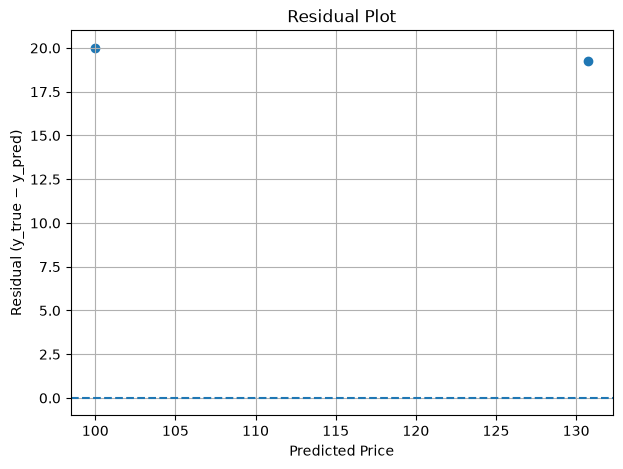

In [15]:

#Step 6

residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (y_true − y_pred)")
plt.title("Residual Plot")
plt.show()

In [16]:
# Q6 – Student Answer

# Part 1: threshold based classification
y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])

# Write your code for threshold 0.5 and 0.3 below
y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])

# Threshold = 0.5
threshold_05 = 0.5
y_pred_05 = (y_prob >= threshold_05).astype(int)

print("Predictions at threshold 0.5:")
print(y_pred_05)

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred_05))

print("Precision:", precision_score(y_true, y_pred_05))
print("Recall:", recall_score(y_true, y_pred_05))
print("F1 Score:", f1_score(y_true, y_pred_05))

# Threshold = 0.3
threshold_03 = 0.3
y_pred_03 = (y_prob >= threshold_03).astype(int)

print("\nPredictions at threshold 0.3:")
print(y_pred_03)

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred_03))

print("Precision:", precision_score(y_true, y_pred_03))
print("Recall:", recall_score(y_true, y_pred_03))
print("F1 Score:", f1_score(y_true, y_pred_03))

Predictions at threshold 0.5:
[1 0 1 0 1 0 1 0 1 0]

Confusion Matrix:
[[5 0]
 [0 5]]
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Predictions at threshold 0.3:
[1 0 1 0 1 1 1 1 1 0]

Confusion Matrix:
[[3 2]
 [0 5]]
Precision: 0.7142857142857143
Recall: 1.0
F1 Score: 0.8333333333333334


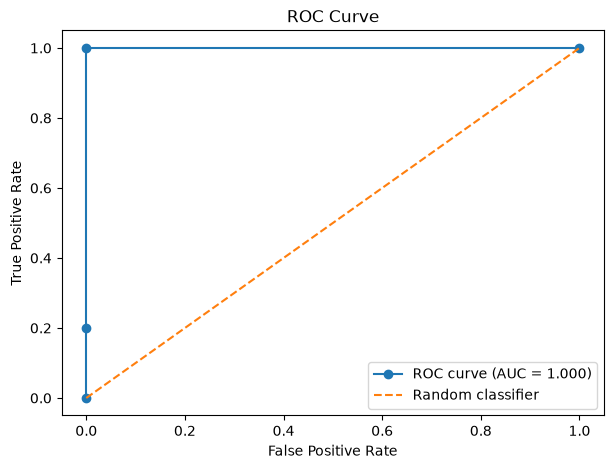

AUC: 1.000


In [17]:
# Part 2: ROC and AUC
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

# Calculate AUC
auc = roc_auc_score(y_true, y_prob)

# Plot ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, marker='o', label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

print(f"AUC: {auc:.3f}")

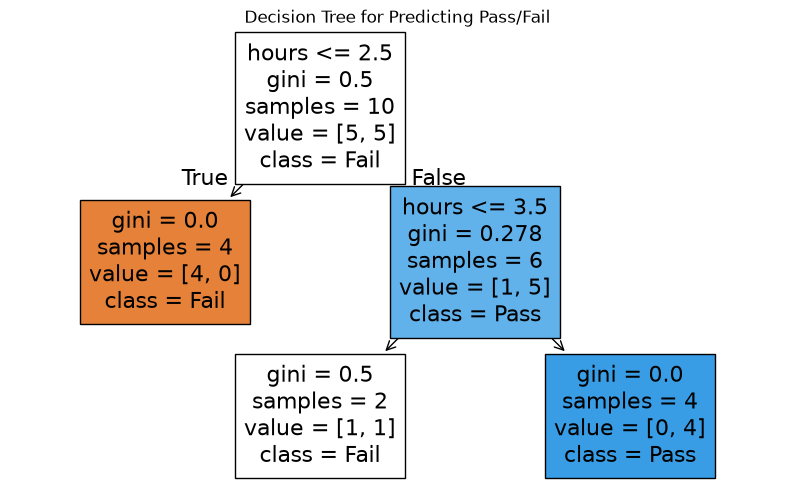

In [18]:
# Part 3: Decision Tree
df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})

df3

# FItting the Tree
X = df3[["hours"]]
y = df3["passed"]

tree_model = DecisionTreeClassifier(max_depth=2, random_state=42)

tree_model.fit(X, y)

# Plotting the tree
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 6))

plot_tree(
    tree_model,
    feature_names=["hours"],
    class_names=["Fail", "Pass"],
    filled=True
)

plt.title("Decision Tree for Predicting Pass/Fail")
plt.show()